In [1]:
import pandas as pd

df = pd.read_csv("data.csv", sep=";")
df.columns = df.columns.str.strip()

df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
print(df.columns.tolist())

['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Target']


In [5]:
df.shape

(4424, 37)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

In [9]:
df["Target"].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [11]:
df["Target"].value_counts(normalize=True) * 100

Target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64

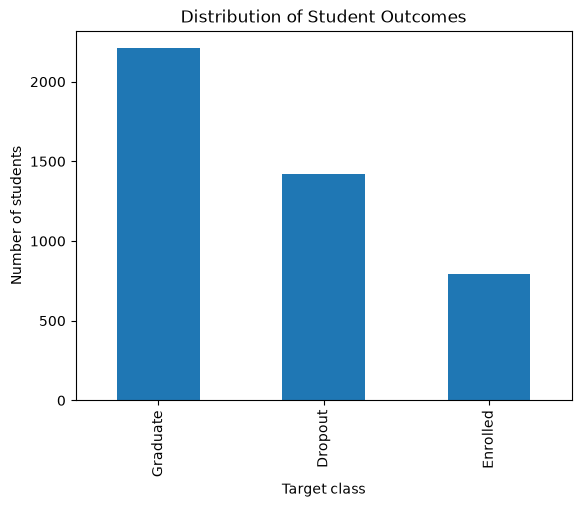

In [13]:
import matplotlib.pyplot as plt
df["Target"].value_counts().plot(kind="bar")
plt.xlabel("Target class")
plt.ylabel("Number of students")
plt.title("Distribution of Student Outcomes")
plt.show()

In [15]:
X = df.drop(columns = ["Target"])
y = df["Target"]
print(X.shape)
print(y.shape)

(4424, 36)
(4424,)


In [17]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
print(encoder.classes_)

['Dropout' 'Enrolled' 'Graduate']


In [19]:
y_encoded[:10]

array([0, 2, 0, 2, 2, 2, 2, 0, 2, 0])

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_valtest, y_train, y_valtest = train_test_split(X, y_encoded, test_size = 0.30,stratify = y_encoded, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_valtest, y_valtest, test_size = 0.50,stratify = y_valtest, random_state=42)

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = ["Marital status", "Application mode", "Course", "Previous qualification",
    "Nacionality", "Mother's qualification", "Father's qualification", "Mother's occupation",
    "Father's occupation"]

numerical_features = ["Application order", "Previous qualification (grade)", "Admission grade",
    "Age at enrollment", "Curricular units 1st sem (credited)", "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)", "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)", "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (credited)", "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)", "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)", "Curricular units 2nd sem (without evaluations)",
    "Unemployment rate", "Inflation rate", "GDP",]

binary_features = ["Daytime/evening attendance", "Displaced", "Educational special needs",
    "Debtor", "Tuition fees up to date", "Gender", "Scholarship holder", "International"]

preprocessor = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("numerical", StandardScaler(), numerical_features),
    ("binary", "passthrough", binary_features)])

In [25]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_val_preprocessed = preprocessor.transform(X_val)
X_test_preprocessed = preprocessor.transform(X_test)

In [29]:
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import numpy as np

results = []

for n_hidden in [1, 3, 5, 10]:

    np.random.seed(42)
    tf.random.set_seed(42)

    model = keras.Sequential([
        keras.layers.Input(shape=(X_train_preprocessed.shape[1],)),
        keras.layers.Dense(n_hidden, activation="relu"),
        keras.layers.Dense(3, activation="softmax")])

    model.compile(optimizer="sgd", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    
    history = model.fit(X_train_preprocessed,y_train,validation_data=(X_val_preprocessed, y_val),epochs=100,batch_size=32,verbose=0)

    best_epoch = np.argmax(history.history["val_accuracy"]) + 1

    best_val_accuracy = max(history.history["val_accuracy"])

    results.append({"Hidden neurons": n_hidden, "Best epoch": best_epoch,"Best validation accuracy": best_val_accuracy})

baseline_tuning = pd.DataFrame(results)

baseline_tuning

,Hidden neurons,Best epoch,Best validation accuracy
0,1,50,0.743976
1,3,90,0.775602
2,5,32,0.768072
3,10,32,0.772590


In [115]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

np.random.seed(42)
tf.random.set_seed(42)

baseline_model = keras.Sequential([
    keras.layers.Input(shape=(X_train_preprocessed.shape[1],)),
    keras.layers.Dense(3, activation="relu"),
    keras.layers.Dense(3, activation="softmax")])

baseline_model.compile(optimizer="sgd",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

checkpoint_baseline_3hidden = keras.callbacks.ModelCheckpoint("best_baseline_3hidden.weights.h5",monitor="val_accuracy",mode="max",save_best_only=True,
    save_weights_only=True,verbose=1)

baseline_history_3hidden = baseline_model.fit(X_train_preprocessed,y_train,validation_data=(X_val_preprocessed, y_val),epochs=100,batch_size=32,
    callbacks=[checkpoint_baseline_3hidden],verbose=1)

baseline_model.load_weights("best_baseline_3hidden.weights.h5")

best_epoch_baseline = (np.argmax(baseline_history_3hidden.history["val_accuracy"]) + 1)

best_val_accuracy_baseline = max(baseline_history_3hidden.history["val_accuracy"])

print("Best epoch:", best_epoch_baseline)
print("Best validation accuracy:",best_val_accuracy_baseline)

Epoch 1/100
89/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5407 - loss: 1.0357 
Epoch 1: val_accuracy improved from None to 0.64910, saving model to best_baseline_3hidden.weights.h5

Epoch 1: finished saving model to best_baseline_3hidden.weights.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5478 - loss: 1.0286 - val_accuracy: 0.6491 - val_loss: 0.9485
Epoch 2/100
46/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6909 - loss: 0.9037 
Epoch 2: val_accuracy improved from 0.64910 to 0.68223, saving model to best_baseline_3hidden.weights.h5

Epoch 2: finished saving model to best_baseline_3hidden.weights.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6890 - loss: 0.8943 - val_accuracy: 0.6822 - val_loss: 0.8933
Epoch 3/100
81/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7060 - loss: 0.8381
Epoch 3: val_accuracy improved from 0.68223 to 0.69127, saving model to best_baseline_3hidden.weights.h5

Epoch 3: finished saving model to best_baseline_3hidden.weights.

In [117]:
baseline_test_loss, baseline_test_accuracy = (baseline_model.evaluate(X_test_preprocessed,y_test,verbose=0))
print("Baseline test loss:", baseline_test_loss)
print("Baseline test accuracy:", baseline_test_accuracy)

Baseline test loss: 0.5105268359184265
Baseline test accuracy: 0.7936747074127197


In [121]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score)

y_baseline_pred_probs = baseline_model.predict(X_test_preprocessed,verbose=0)

y_baseline_pred = np.argmax(y_baseline_pred_probs,axis=1)

print("Accuracy:", accuracy_score(y_test, y_baseline_pred))
print("Macro precision:", precision_score(y_test, y_baseline_pred, average="macro"))
print("Macro recall:", recall_score(y_test, y_baseline_pred, average="macro"))
print("Macro F1:", f1_score(y_test, y_baseline_pred, average="macro"))

Accuracy: 0.7936746987951807
Macro precision: 0.7433364374773656
Macro recall: 0.710429537034906
Macro F1: 0.7207556030509094


In [37]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

In [129]:
y_baseline_pred_probs = baseline_model.predict(X_test_preprocessed,verbose=0)

y_baseline_pred = np.argmax(y_baseline_pred_probs,axis=1)

print(classification_report(y_test,y_baseline_pred,target_names=["Dropout", "Enrolled", "Graduate"],digits=4))

baseline_conf_matr = confusion_matrix(y_test,y_baseline_pred)

print("Baseline confusion matrix:")
print(baseline_conf_matr)

              precision    recall  f1-score   support

     Dropout     0.8500    0.7944    0.8213       214
    Enrolled     0.5647    0.4034    0.4706       119
    Graduate     0.8153    0.9335    0.8704       331

    accuracy                         0.7937       664
   macro avg     0.7433    0.7104    0.7208       664
weighted avg     0.7816    0.7937    0.7829       664

Baseline confusion matrix:
[[170  21  23]
 [ 24  48  47]
 [  6  16 309]]


In [41]:
unique, counts = np.unique(y_test, return_counts=True)
class_names = ["Dropout", "Enrolled", "Graduate"]

for cls, count in zip(unique, counts):
    print(f"{class_names[cls]}: {count}")

Dropout: 214
Enrolled: 119
Graduate: 331


In [ ]:
##start of incremental learning

In [43]:
stage1_train_mask = np.isin(y_train, [0, 1])
stage1_val_mask = np.isin(y_val, [0, 1])
stage1_test_mask = np.isin(y_test, [0, 1])

X_stage1_train = X_train_preprocessed[stage1_train_mask]
y_stage1_train = y_train[stage1_train_mask]

X_stage1_val = X_val_preprocessed[stage1_val_mask]
y_stage1_val = y_val[stage1_val_mask]

X_stage1_test = X_test_preprocessed[stage1_test_mask]
y_stage1_test = y_test[stage1_test_mask]

In [45]:
print("Training:", np.unique(y_stage1_train, return_counts=True))
print("Validation:", np.unique(y_stage1_val, return_counts=True))
print("Test:", np.unique(y_stage1_test, return_counts=True))

Training: (array([0, 1]), array([994, 556]))
Validation: (array([0, 1]), array([213, 119]))
Test: (array([0, 1]), array([214, 119]))


In [47]:
np.random.seed(42)
tf.random.set_seed(42)

stage1_model = keras.Sequential([
    keras.layers.Input(shape=(X_stage1_train.shape[1],)),
    keras.layers.Dense(2, activation="softmax")])

stage1_model.compile(optimizer="sgd",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [49]:
stage1_history = stage1_model.fit(X_stage1_train,y_stage1_train,validation_data=(X_stage1_val, y_stage1_val),
    epochs=100,batch_size=32,verbose=1)

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6232 - loss: 0.6382 - val_accuracy: 0.6355 - val_loss: 0.6115
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6755 - loss: 0.5661 - val_accuracy: 0.6386 - val_loss: 0.5953
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6994 - loss: 0.5394 - val_accuracy: 0.6596 - val_loss: 0.5884
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7232 - loss: 0.5230 - val_accuracy: 0.6777 - val_loss: 0.5844
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7271 - loss: 0.5118 - val_accuracy: 0.6777 - val_loss: 0.5815
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7381 - loss: 0.5034 - val_accuracy: 0.6958 - val_loss: 0.5791
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7516 - loss: 0.4968 - val_accuracy: 0.7078 - val_loss: 0.5768
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7581 - loss: 0.4913 - val_accuracy: 0.710

In [51]:
stage1_history.history["accuracy"]

[0.6232258081436157,
 0.6754838824272156,
 0.6993548274040222,
 0.7232258319854736,
 0.7270967960357666,
 0.7380645275115967,
 0.7516129016876221,
 0.7580645084381104,
 0.7619354724884033,
 0.7683870792388916,
 0.7709677219390869,
 0.7754838466644287,
 0.7774193286895752,
 0.7799999713897705,
 0.7799999713897705,
 0.7851613163948059,
 0.7877419590950012,
 0.792258083820343,
 0.7935484051704407,
 0.7929032444953918,
 0.7954838871955872,
 0.7974193692207336,
 0.7954838871955872,
 0.796129047870636,
 0.796129047870636,
 0.7967742085456848,
 0.7967742085456848,
 0.7967742085456848,
 0.7987096905708313,
 0.7987096905708313,
 0.7987096905708313,
 0.7993548512458801,
 0.7980645298957825,
 0.7987096905708313,
 0.7980645298957825,
 0.7967742085456848,
 0.7967742085456848,
 0.7967742085456848,
 0.796129047870636,
 0.7974193692207336,
 0.7980645298957825,
 0.7974193692207336,
 0.7987096905708313,
 0.800000011920929,
 0.8006451725959778,
 0.8006451725959778,
 0.8025806546211243,
 0.801935493946075

In [53]:
stage1_history.history["val_accuracy"]

[0.6355421543121338,
 0.6385542154312134,
 0.6596385836601257,
 0.6777108311653137,
 0.6777108311653137,
 0.6957831382751465,
 0.7078313231468201,
 0.7108433842658997,
 0.7138554453849792,
 0.7228915691375732,
 0.7259036302566528,
 0.7259036302566528,
 0.7259036302566528,
 0.7228915691375732,
 0.7259036302566528,
 0.7259036302566528,
 0.7289156913757324,
 0.7349397540092468,
 0.7349397540092468,
 0.7379518151283264,
 0.7379518151283264,
 0.7439758777618408,
 0.7439758777618408,
 0.7439758777618408,
 0.7379518151283264,
 0.7439758777618408,
 0.7469879388809204,
 0.75,
 0.75,
 0.75,
 0.7469879388809204,
 0.7469879388809204,
 0.7469879388809204,
 0.75,
 0.75,
 0.75,
 0.75,
 0.75,
 0.75,
 0.7469879388809204,
 0.7439758777618408,
 0.7439758777618408,
 0.7439758777618408,
 0.7439758777618408,
 0.7439758777618408,
 0.740963876247406,
 0.740963876247406,
 0.740963876247406,
 0.740963876247406,
 0.7469879388809204,
 0.75,
 0.7530120611190796,
 0.7530120611190796,
 0.7530120611190796,
 0.7560241

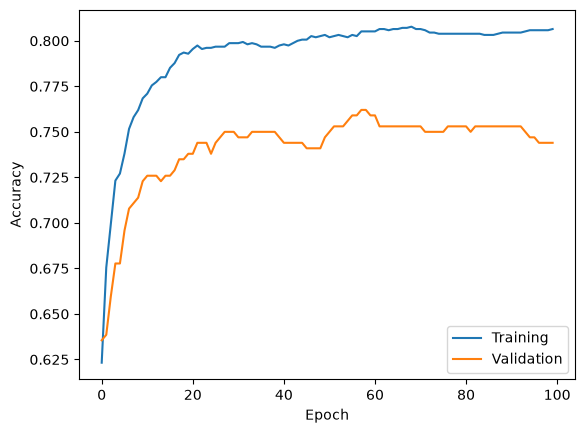

In [55]:
import matplotlib.pyplot as plt

plt.plot(stage1_history.history["accuracy"], label="Training")
plt.plot(stage1_history.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [57]:
np.random.seed(42)
tf.random.set_seed(42)

stage1_model_1hidden = keras.Sequential([
    keras.layers.Input(shape=(X_stage1_train.shape[1],)),
    keras.layers.Dense(1, activation="relu"),
    keras.layers.Dense(2, activation="softmax")])

stage1_model_1hidden.compile(optimizer="sgd",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [59]:
stage1_history_1hidden = stage1_model_1hidden.fit(X_stage1_train, y_stage1_train, validation_data=(X_stage1_val, y_stage1_val),
    epochs=100,batch_size=32,verbose=1)

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5968 - loss: 0.7137 - val_accuracy: 0.6265 - val_loss: 0.6835
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6219 - loss: 0.6814 - val_accuracy: 0.6325 - val_loss: 0.6674
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6245 - loss: 0.6667 - val_accuracy: 0.6235 - val_loss: 0.6589
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6316 - loss: 0.6586 - val_accuracy: 0.6325 - val_loss: 0.6537
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6381 - loss: 0.6531 - val_accuracy: 0.6416 - val_loss: 0.6491
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6394 - loss: 0.6480 - val_accuracy: 0.6386 - val_loss: 0.6444
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6477 - loss: 0.6411 - val_accuracy: 0.6506 - val_loss: 0.6371
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6600 - loss: 0.6293 - val_accuracy: 0.6

In [61]:
best_epoch = np.argmax(stage1_history_1hidden.history["val_accuracy"]) + 1
best_val_accuracy = max(stage1_history_1hidden.history["val_accuracy")
print("Best epoch:", best_epoch)
print("Best validation accuracy:", best_val_accuracy)

Best epoch: 72
Best validation accuracy: 0.7530120611190796


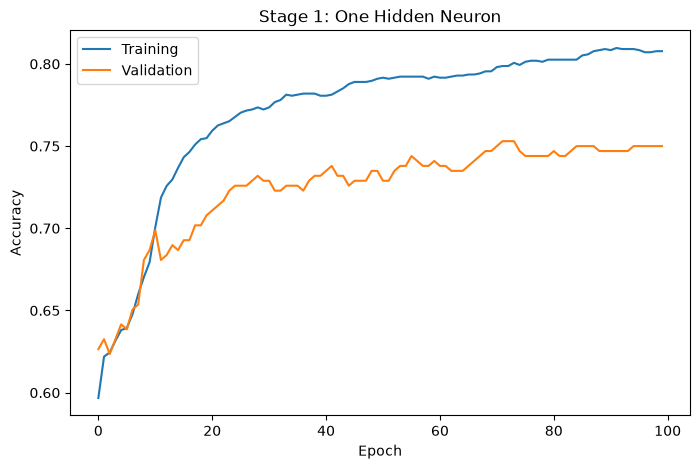

In [63]:
plt.figure(figsize=(8, 5))

plt.plot(stage1_history_1hidden.history["accuracy"],label="Training")

plt.plot(stage1_history_1hidden.history["val_accuracy"],label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Stage 1: One Hidden Neuron")
plt.legend()
plt.show()

In [65]:
np.random.seed(42)
tf.random.set_seed(42)

stage1_model_2hidden = keras.Sequential([
    keras.layers.Input(shape=(X_stage1_train.shape[1],)),
    keras.layers.Dense(2, activation="relu"),
    keras.layers.Dense(2, activation="softmax")])

stage1_model_2hidden.compile(optimizer="sgd",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

stage1_history_2hidden = stage1_model_2hidden.fit(X_stage1_train,y_stage1_train,validation_data=(X_stage1_val, y_stage1_val),epochs=100,
    batch_size=32,verbose=1)

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6271 - loss: 0.6343 - val_accuracy: 0.6476 - val_loss: 0.6091
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6606 - loss: 0.5863 - val_accuracy: 0.6777 - val_loss: 0.5898
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6787 - loss: 0.5616 - val_accuracy: 0.6747 - val_loss: 0.5802
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7090 - loss: 0.5443 - val_accuracy: 0.6867 - val_loss: 0.5743
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7232 - loss: 0.5314 - val_accuracy: 0.6867 - val_loss: 0.5707
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7355 - loss: 0.5215 - val_accuracy: 0.6867 - val_loss: 0.5683
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7413 - loss: 0.5132 - val_accuracy: 0.6837 - val_loss: 0.5666
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7542 - loss: 0.5063 - val_accuracy: 0.

In [67]:
best_epoch_2hidden = np.argmax(stage1_history_2hidden.history["val_accuracy"]) + 1

best_val_accuracy_2hidden = max(stage1_history_2hidden.history["val_accuracy"])
print("Best epoch:", best_epoch_2hidden)
print("Best validation accuracy:", best_val_accuracy_2hidden)

Best epoch: 94
Best validation accuracy: 0.7439758777618408


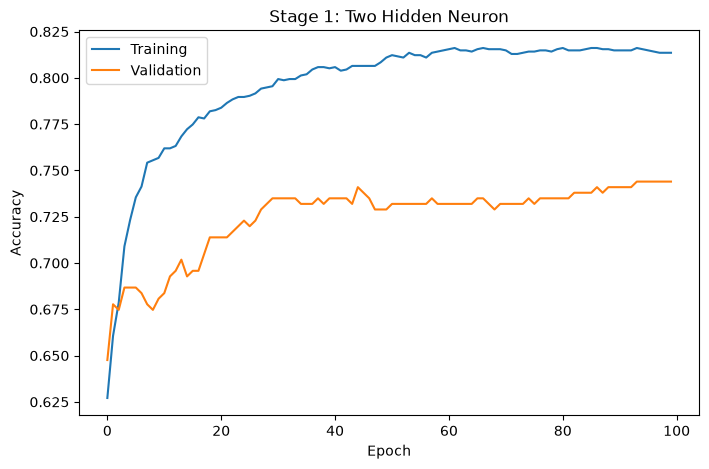

In [69]:
plt.figure(figsize=(8, 5))

plt.plot(stage1_history_2hidden.history["accuracy"],label="Training")
plt.plot(stage1_history_2hidden.history["val_accuracy"],label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Stage 1: Two Hidden Neuron")
plt.legend()
plt.show()

In [71]:
np.random.seed(42)
tf.random.set_seed(42)

stage2_model_1hidden = keras.Sequential([
    keras.layers.Input(shape=(X_train_preprocessed.shape[1],)),
    keras.layers.Dense(1, activation="relu"),
    keras.layers.Dense(3, activation="softmax")])

stage2_model_1hidden.build(input_shape=(None, X_train_preprocessed.shape[1]))

old_hidden_weights, old_hidden_bias = (stage1_model_1hidden.layers[0].get_weights())

old_output_weights, old_output_bias = (stage1_model_1hidden.layers[1].get_weights())

new_hidden_weights, new_hidden_bias = (stage2_model_1hidden.layers[0].get_weights())

new_output_weights, new_output_bias = (stage2_model_1hidden.layers[1].get_weights())

new_hidden_weights[:, 0] = old_hidden_weights[:, 0]
new_hidden_bias[0] = old_hidden_bias[0]

new_output_weights[:, :2] = old_output_weights
new_output_bias[:2] = old_output_bias

stage2_model_1hidden.layers[0].set_weights([new_hidden_weights,new_hidden_bias])

stage2_model_1hidden.layers[1].set_weights([new_output_weights,new_output_bias])

stage2_model_1hidden.compile(optimizer="sgd",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

checkpoint_stage2_1hidden = keras.callbacks.ModelCheckpoint("best_stage2_1hidden.weights.h5",monitor="val_accuracy",mode="max",save_best_only=True,
    save_weights_only=True,verbose=1)

In [73]:
stage2_history_1hidden = stage2_model_1hidden.fit(X_train_preprocessed,y_train,validation_data=(X_val_preprocessed, y_val),
    epochs=100,batch_size=32,callbacks=[checkpoint_stage2_1hidden],verbose=1)

Epoch 1/100
90/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7028 - loss: 0.7819
Epoch 1: val_accuracy improved from None to 0.69729, saving model to best_stage2_1hidden.weights.h5

Epoch 1: finished saving model to best_stage2_1hidden.weights.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7022 - loss: 0.7817 - val_accuracy: 0.6973 - val_loss: 0.8182
Epoch 2/100
85/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7140 - loss: 0.7486
Epoch 2: val_accuracy did not improve from 0.69729
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7129 - loss: 0.7510 - val_accuracy: 0.6943 - val_loss: 0.8031
Epoch 3/100
89/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7170 - loss: 0.7364
Epoch 3: val_accuracy improved from 0.69729 to 0.70181, saving model to best_stage2_1hidden.weights.h5

Epoch 3: finished saving model to best_stage2_1hidden.weights.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7158 - loss: 0.7386 - val_accuracy: 0.7018 - val_loss: 0.7942
Epoch 4/100
9

In [75]:
stage2_model_1hidden.load_weights("best_stage2_1hidden.weights.h5")

In [77]:
best_epoch_stage2_1hidden = (np.argmax(stage2_history_1hidden.history["val_accuracy"]) + 1)

best_val_accuracy_stage2_1hidden = max(stage2_history_1hidden.history["val_accuracy"])

print("Best epoch:", best_epoch_stage2_1hidden)
print("Best validation accuracy:",best_val_accuracy_stage2_1hidden)

Best epoch: 19
Best validation accuracy: 0.7349397540092468


In [79]:

np.random.seed(42)
tf.random.set_seed(42)

stage2_model_2hidden = keras.Sequential([
    keras.layers.Input(shape=(X_train_preprocessed.shape[1],)),
    keras.layers.Dense(2, activation="relu"),
    keras.layers.Dense(3, activation="softmax")])

stage2_model_2hidden.build(input_shape=(None, X_train_preprocessed.shape[1]))
old_hidden_weights, old_hidden_bias = (stage2_model_1hidden.layers[0].get_weights())

old_output_weights, old_output_bias = (stage2_model_1hidden.layers[1].get_weights())

new_hidden_weights, new_hidden_bias = (stage2_model_2hidden.layers[0].get_weights())

new_output_weights, new_output_bias = (stage2_model_2hidden.layers[1].get_weights())


new_hidden_weights[:, 0] = old_hidden_weights[:, 0]
new_hidden_bias[0] = old_hidden_bias[0]

new_output_weights[0, :] = old_output_weights[0, :]
new_output_bias[:] = old_output_bias

stage2_model_2hidden.layers[0].set_weights([new_hidden_weights,new_hidden_bias])

stage2_model_2hidden.layers[1].set_weights([new_output_weights,new_output_bias])

stage2_model_2hidden.compile(optimizer="sgd",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [81]:
checkpoint_stage2_2hidden = keras.callbacks.ModelCheckpoint("best_stage2_2hidden.weights.h5",monitor="val_accuracy",mode="max",
    save_best_only=True,save_weights_only=True,verbose=1)

In [83]:
stage2_history_2hidden = stage2_model_2hidden.fit(X_train_preprocessed,y_train,validation_data=(X_val_preprocessed, y_val),
    epochs=100,batch_size=32,callbacks=[checkpoint_stage2_2hidden],verbose=1)

Epoch 1/100
95/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7408 - loss: 0.6618
Epoch 1: val_accuracy improved from None to 0.73042, saving model to best_stage2_2hidden.weights.h5

Epoch 1: finished saving model to best_stage2_2hidden.weights.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7422 - loss: 0.6589 - val_accuracy: 0.7304 - val_loss: 0.7280
Epoch 2/100
89/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7444 - loss: 0.6544
Epoch 2: val_accuracy improved from 0.73042 to 0.73343, saving model to best_stage2_2hidden.weights.h5

Epoch 2: finished saving model to best_stage2_2hidden.weights.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7432 - loss: 0.6554 - val_accuracy: 0.7334 - val_loss: 0.7249
Epoch 3/100
82/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7477 - loss: 0.6432
Epoch 3: val_accuracy did not improve from 0.73343
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7432 - loss: 0.6523 - val_accuracy: 0.7334 - val_loss: 0.7221
Epoch 4/100
9

In [85]:
stage2_model_2hidden.load_weights("best_stage2_2hidden.weights.h5")

best_epoch_stage2_2hidden = (np.argmax(stage2_history_2hidden.history["val_accuracy"]) + 1)

best_val_accuracy_stage2_2hidden = max(stage2_history_2hidden.history["val_accuracy"])

print("Best epoch:", best_epoch_stage2_2hidden)
print("Best validation accuracy:",best_val_accuracy_stage2_2hidden)

Best epoch: 97
Best validation accuracy: 0.7620481848716736


In [87]:
np.random.seed(42)
tf.random.set_seed(42)

stage2_model_3hidden = keras.Sequential([
    keras.layers.Input(shape=(X_train_preprocessed.shape[1],)),
    keras.layers.Dense(3, activation="relu"),
    keras.layers.Dense(3, activation="softmax")])

stage2_model_3hidden.build(input_shape=(None, X_train_preprocessed.shape[1]))

old_hidden_weights, old_hidden_bias = (stage2_model_2hidden.layers[0].get_weights())

old_output_weights, old_output_bias = (stage2_model_2hidden.layers[1].get_weights())

new_hidden_weights, new_hidden_bias = (stage2_model_3hidden.layers[0].get_weights())

new_output_weights, new_output_bias = (stage2_model_3hidden.layers[1].get_weights())

new_hidden_weights[:, :2] = old_hidden_weights
new_hidden_bias[:2] = old_hidden_bias

new_output_weights[:2, :] = old_output_weights
new_output_bias[:] = old_output_bias

stage2_model_3hidden.layers[0].set_weights([new_hidden_weights,new_hidden_bias])

stage2_model_3hidden.layers[1].set_weights([new_output_weights,new_output_bias])

stage2_model_3hidden.compile(optimizer="sgd",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [91]:
checkpoint_stage2_3hidden = keras.callbacks.ModelCheckpoint("best_stage2_3hidden.weights.h5",monitor="val_accuracy",
    mode="max",save_best_only=True,save_weights_only=True,verbose=1)

In [93]:
stage2_history_3hidden = stage2_model_3hidden.fit(X_train_preprocessed,y_train,validation_data=(X_val_preprocessed, y_val),
    epochs=100,batch_size=32,callbacks=[checkpoint_stage2_3hidden],verbose=1)

Epoch 1/100
89/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7883 - loss: 0.5289
Epoch 1: val_accuracy improved from None to 0.75602, saving model to best_stage2_3hidden.weights.h5

Epoch 1: finished saving model to best_stage2_3hidden.weights.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7878 - loss: 0.5288 - val_accuracy: 0.7560 - val_loss: 0.6259
Epoch 2/100
83/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7880 - loss: 0.5265
Epoch 2: val_accuracy did not improve from 0.75602
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7884 - loss: 0.5263 - val_accuracy: 0.7560 - val_loss: 0.6256
Epoch 3/100
80/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7887 - loss: 0.5241
Epoch 3: val_accuracy did not improve from 0.75602
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7891 - loss: 0.5249 - val_accuracy: 0.7530 - val_loss: 0.6254
Epoch 4/100
82/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7881 - loss: 0.5219
Epoch 4: val_accuracy improved from 0.75602 to

In [95]:
stage2_model_3hidden.load_weights("best_stage2_3hidden.weights.h5")

best_epoch_stage2_3hidden = (np.argmax(stage2_history_3hidden.history["val_accuracy"]) + 1)

best_val_accuracy_stage2_3hidden = max(stage2_history_3hidden.history["val_accuracy"])

print("Best epoch:", best_epoch_stage2_3hidden)
print("Best validation accuracy:",best_val_accuracy_stage2_3hidden)

Best epoch: 46
Best validation accuracy: 0.7695783376693726


In [97]:
best_epoch = np.argmax(stage2_history_3hidden.history["val_accuracy"]) + 1

train_acc = stage2_history_3hidden.history["accuracy"][best_epoch - 1]
val_acc = stage2_history_3hidden.history["val_accuracy"][best_epoch - 1]

print("Best epoch:", best_epoch)
print("Training accuracy:", train_acc)
print("Validation accuracy:", val_acc)
print("Gap:", train_acc - val_acc)

Best epoch: 46
Training accuracy: 0.7936046719551086
Validation accuracy: 0.7695783376693726
Gap: 0.024026334285736084


In [99]:
stage2_model_3hidden.load_weights("best_stage2_3hidden.weights.h5")

np.random.seed(42)
tf.random.set_seed(42)

stage2_model_4hidden = keras.Sequential([
    keras.layers.Input(shape=(X_train_preprocessed.shape[1],)),
    keras.layers.Dense(4, activation="relu"),
    keras.layers.Dense(3, activation="softmax")])

stage2_model_4hidden.build(input_shape=(None, X_train_preprocessed.shape[1]))

old_hidden_weights, old_hidden_bias = (stage2_model_3hidden.layers[0].get_weights())

old_output_weights, old_output_bias = (stage2_model_3hidden.layers[1].get_weights())

new_hidden_weights, new_hidden_bias = (stage2_model_4hidden.layers[0].get_weights())

new_output_weights, new_output_bias = (stage2_model_4hidden.layers[1].get_weights())

new_hidden_weights[:, :3] = old_hidden_weights
new_hidden_bias[:3] = old_hidden_bias

new_output_weights[:3, :] = old_output_weights
new_output_bias[:] = old_output_bias

stage2_model_4hidden.layers[0].set_weights([new_hidden_weights,new_hidden_bias])

stage2_model_4hidden.layers[1].set_weights([new_output_weights,new_output_bias])

stage2_model_4hidden.compile(optimizer="sgd",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [101]:
checkpoint_stage2_4hidden = keras.callbacks.ModelCheckpoint("best_stage2_4hidden.weights.h5",monitor="val_accuracy",mode="max",
    save_best_only=True,save_weights_only=True,verbose=1)

stage2_history_4hidden = stage2_model_4hidden.fit(X_train_preprocessed,y_train,validation_data=(X_val_preprocessed, y_val),epochs=100,batch_size=32,
    callbacks=[checkpoint_stage2_4hidden],verbose=1)

Epoch 1/100
90/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7917 - loss: 0.5185
Epoch 1: val_accuracy improved from None to 0.76657, saving model to best_stage2_4hidden.weights.h5

Epoch 1: finished saving model to best_stage2_4hidden.weights.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7907 - loss: 0.5177 - val_accuracy: 0.7666 - val_loss: 0.6246
Epoch 2/100
87/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7920 - loss: 0.5161
Epoch 2: val_accuracy did not improve from 0.76657
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7913 - loss: 0.5145 - val_accuracy: 0.7620 - val_loss: 0.6229
Epoch 3/100
80/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7922 - loss: 0.5130
Epoch 3: val_accuracy did not improve from 0.76657
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7920 - loss: 0.5135 - val_accuracy: 0.7620 - val_loss: 0.6224
Epoch 4/100
81/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7924 - loss: 0.5117
Epoch 4: val_accuracy did not improve from 0.7

In [103]:
stage2_model_4hidden.load_weights("best_stage2_4hidden.weights.h5")

best_epoch_stage2_4hidden = (np.argmax(stage2_history_4hidden.history["val_accuracy"]) + 1)

best_val_accuracy_stage2_4hidden = max(stage2_history_4hidden.history["val_accuracy"])

print("Best epoch:", best_epoch_stage2_4hidden)
print("Best validation accuracy:",best_val_accuracy_stage2_4hidden)

Best epoch: 28
Best validation accuracy: 0.7695783376693726


In [105]:
stage2_model_4hidden.load_weights("best_stage2_4hidden.weights.h5")

np.random.seed(42)
tf.random.set_seed(42)

stage2_model_5hidden = keras.Sequential([
    keras.layers.Input(shape=(X_train_preprocessed.shape[1],)),
    keras.layers.Dense(5, activation="relu"),
    keras.layers.Dense(3, activation="softmax")])

stage2_model_5hidden.build(input_shape=(None, X_train_preprocessed.shape[1]))

old_hidden_weights, old_hidden_bias = (stage2_model_4hidden.layers[0].get_weights())

old_output_weights, old_output_bias = (stage2_model_4hidden.layers[1].get_weights())

new_hidden_weights, new_hidden_bias = (stage2_model_5hidden.layers[0].get_weights())

new_output_weights, new_output_bias = (stage2_model_5hidden.layers[1].get_weights())

new_hidden_weights[:, :4] = old_hidden_weights
new_hidden_bias[:4] = old_hidden_bias

new_output_weights[:4, :] = old_output_weights

new_output_bias[:] = old_output_bias

stage2_model_5hidden.layers[0].set_weights([new_hidden_weights,new_hidden_bias])

stage2_model_5hidden.layers[1].set_weights([new_output_weights,new_output_bias])

stage2_model_5hidden.compile(optimizer="sgd",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [107]:
checkpoint_stage2_5hidden = keras.callbacks.ModelCheckpoint("best_stage2_5hidden.weights.h5",monitor="val_accuracy",
    mode="max",save_best_only=True,save_weights_only=True,verbose=1)

stage2_history_5hidden = stage2_model_5hidden.fit(X_train_preprocessed,y_train,validation_data=(X_val_preprocessed, y_val),epochs=100,
    batch_size=32,callbacks=[checkpoint_stage2_5hidden],verbose=1)

Epoch 1/100
84/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7935 - loss: 0.5063
Epoch 1: val_accuracy improved from None to 0.76958, saving model to best_stage2_5hidden.weights.h5

Epoch 1: finished saving model to best_stage2_5hidden.weights.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7946 - loss: 0.5056 - val_accuracy: 0.7696 - val_loss: 0.6207
Epoch 2/100
78/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7965 - loss: 0.5030
Epoch 2: val_accuracy did not improve from 0.76958
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7968 - loss: 0.5051 - val_accuracy: 0.7696 - val_loss: 0.6212
Epoch 3/100
83/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7989 - loss: 0.5052
Epoch 3: val_accuracy did not improve from 0.76958
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7991 - loss: 0.5047 - val_accuracy: 0.7696 - val_loss: 0.6214
Epoch 4/100
84/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7991 - loss: 0.5050
Epoch 4: val_accuracy did not improve from 0.7

In [109]:
stage2_model_5hidden.load_weights("best_stage2_5hidden.weights.h5")

best_epoch_stage2_5hidden = (np.argmax(stage2_history_5hidden.history["val_accuracy"]) + 1)

best_val_accuracy_stage2_5hidden = max(stage2_history_5hidden.history["val_accuracy"])

print("Best epoch:", best_epoch_stage2_5hidden)
print("Best validation accuracy:",best_val_accuracy_stage2_5hidden)

Best epoch: 68
Best validation accuracy: 0.7725903391838074


In [111]:
stage2_model_5hidden.load_weights("best_stage2_5hidden.weights.h5")

test_loss_incremental, test_accuracy_incremental = (stage2_model_5hidden.evaluate(X_test_preprocessed,y_test,verbose=0))

print("Incremental test loss:", test_loss_incremental)
print("Incremental test accuracy:", test_accuracy_incremental)

Incremental test loss: 0.5161356925964355
Incremental test accuracy: 0.7981927990913391


In [113]:
from sklearn.metrics import classification_report, confusion_matrix

y_test_pred_probs = stage2_model_5hidden.predict(X_test_preprocessed,verbose=0)

y_test_pred = np.argmax(y_test_pred_probs, axis=1)

print(classification_report(y_test,y_test_pred,target_names=encoder.classes_))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_test_pred))

              precision    recall  f1-score   support

     Dropout       0.83      0.82      0.83       214
    Enrolled       0.62      0.44      0.51       119
    Graduate       0.82      0.91      0.86       331

    accuracy                           0.80       664
   macro avg       0.76      0.72      0.73       664
weighted avg       0.79      0.80      0.79       664

Confusion matrix:
[[176  15  23]
 [ 23  52  44]
 [ 12  17 302]]


In [125]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

baseline_predictions = baseline_model.predict(X_test_preprocessed).argmax(axis=1)

incremental_predictions = stage2_model_5hidden.predict(X_test_preprocessed).argmax(axis=1)

comparison = pd.DataFrame({
    "Metric": ["Accuracy","Macro precision","Macro recall","Macro F1"],
    "Baseline": [accuracy_score(y_test, baseline_predictions),precision_score(y_test, baseline_predictions, average="macro"),
        recall_score(y_test, baseline_predictions, average="macro"),f1_score(y_test, baseline_predictions, average="macro")],
    "Incremental": [accuracy_score(y_test, incremental_predictions),precision_score(y_test, incremental_predictions, average="macro"),
        recall_score(y_test, incremental_predictions, average="macro"),f1_score(y_test, incremental_predictions, average="macro")]})

comparison

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


,Metric,Baseline,Incremental
0,Accuracy,0.793675,0.798193
1,Macro precision,0.743336,0.757200
2,Macro recall,0.710430,0.723930
3,Macro F1,0.720756,0.734469
